<a href="https://colab.research.google.com/github/llferda/colab-projects/blob/main/XGBoost_Powered_Churn_Prediction_Model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("ecommerce_customer_churn_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42893 entries, 0 to 42892
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            40751 non-null  float64
 1   Gender                         42893 non-null  object 
 2   Country                        42893 non-null  object 
 3   City                           42893 non-null  object 
 4   Membership_Years               42893 non-null  float64
 5   Login_Frequency                42893 non-null  float64
 6   Session_Duration_Avg           39956 non-null  float64
 7   Pages_Per_Session              40304 non-null  float64
 8   Cart_Abandonment_Rate          42893 non-null  float64
 9   Wishlist_Items                 39448 non-null  float64
 10  Total_Purchases                42893 non-null  float64
 11  Average_Order_Value            42893 non-null  float64
 12  Days_Since_Last_Purchase       40312 non-null 

In [4]:
df.isnull().sum()

,0
Age,2142
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,2937
Pages_Per_Session,2589
Cart_Abandonment_Rate,0
Wishlist_Items,3445


In [5]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Eksik verileri doldurma
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')

# Kategorik değişkenleri sayısallaştırma (Label Encoding)
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [6]:
# Hedef (y) ve Özellikler (X)
X = df.drop('Churned', axis=1)
y = df['Churned']

# Eğitim ve test setine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Sınıflandırıcı
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='binary:logistic', # İkili sınıflandırma için
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [7]:
y_pred = model.predict(X_test)

print("Doğruluk Payı (Accuracy):", accuracy_score(y_test, y_pred))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

Doğruluk Payı (Accuracy): 0.9115281501340483

Sınıflandırma Raporu:
               precision    recall  f1-score   support

         0.0       0.91      0.97      0.94      6048
         1.0       0.91      0.77      0.84      2531

    accuracy                           0.91      8579
   macro avg       0.91      0.87      0.89      8579
weighted avg       0.91      0.91      0.91      8579



/tmp/ipython-input-433420274.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_15_importances, palette='viridis')


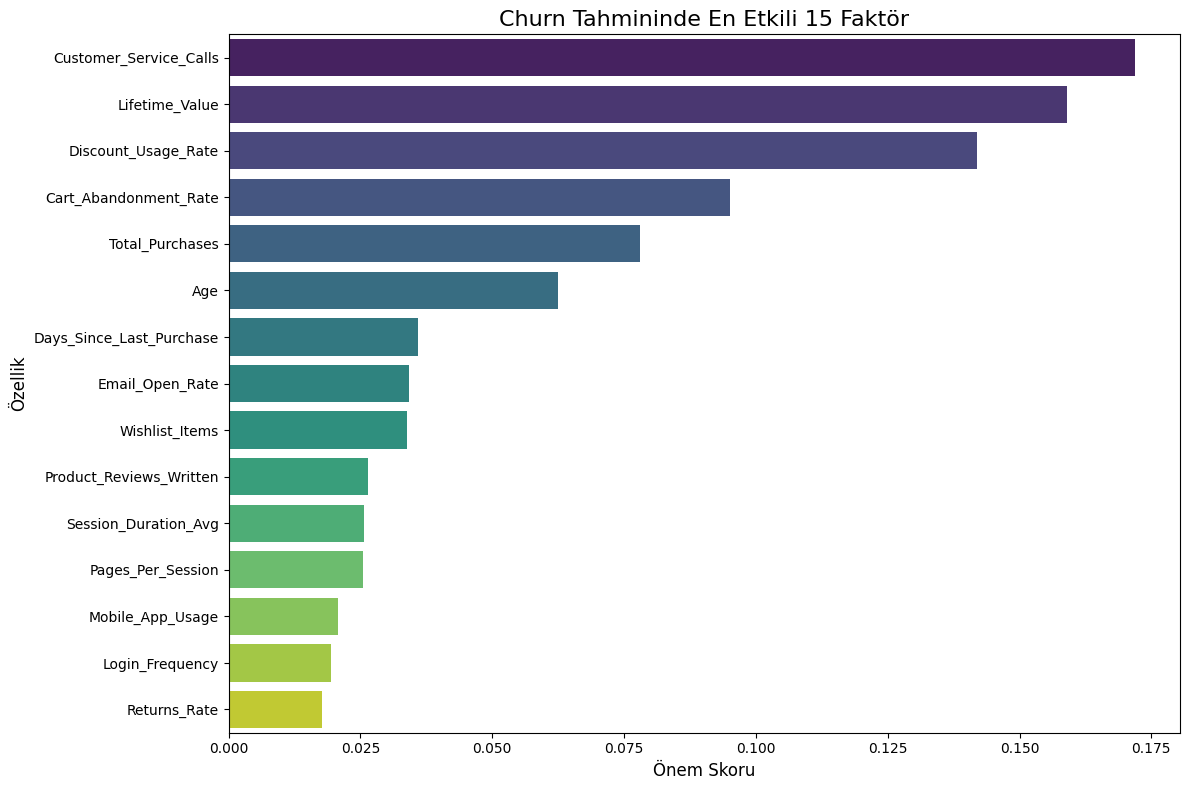

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Özellik önem düzeylerini alalım (already sorted in 'importances' DataFrame)
# İlk 15 özelliği seçelim
top_15_importances = importances.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=top_15_importances, palette='viridis')
plt.title('Churn Tahmininde En Etkili 15 Faktör', fontsize=16)
plt.xlabel('Önem Skoru', fontsize=12)
plt.ylabel('Özellik', fontsize=12)
plt.tight_layout()
plt.show()

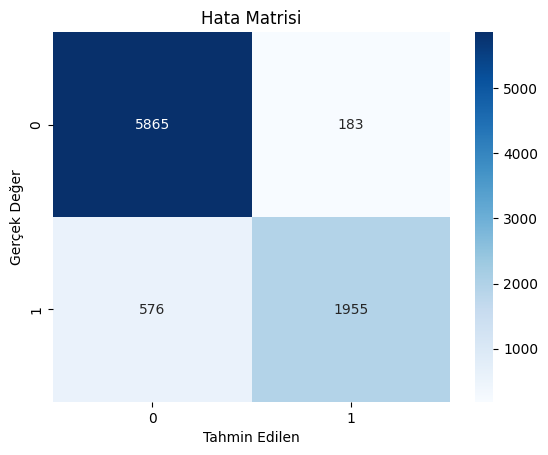

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Hata Matrisi')
plt.show()

In [30]:
# Müşterilerin ayrılma olasılıklarını (olasılık değerlerini) alalım
y_probs = model.predict_proba(X_test)[:, 1] # 1 olma olasılığı

# Test setindeki verilerle olasılıkları birleştirelim
risk_listesi = X_test.copy()
risk_listesi['Churn_Olasiligi'] = y_probs
risk_listesi['Gercek_Durum'] = y_test.values


In [31]:
# En riskli 10 müşteriyi görelim
print(risk_listesi.sort_values(by='Churn_Olasiligi', ascending=False).head(10))

        Age  Gender  Country  City  Membership_Years  Login_Frequency  \
36056  18.0       0        1    38               1.1             16.0   
9195   19.0       1        1     5               0.8             13.0   
16912  21.0       1        7    18               3.3              8.0   
15978  18.0       0        6    16               2.7             10.0   
29415  18.0       0        0     0               0.6             14.0   
9606   18.0       1        3    25               0.9             25.0   
14943  22.0       1        7     7               2.1             12.0   
29606  18.0       0        1    23               0.8             17.0   
30252  22.0       1        5    29               0.7             11.0   
34442  18.0       0        7    18               3.4             16.0   

       Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
36056                  25.9                9.7                   56.7   
9195                   22.8                6.7    

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 4000x2000 with 0 Axes>

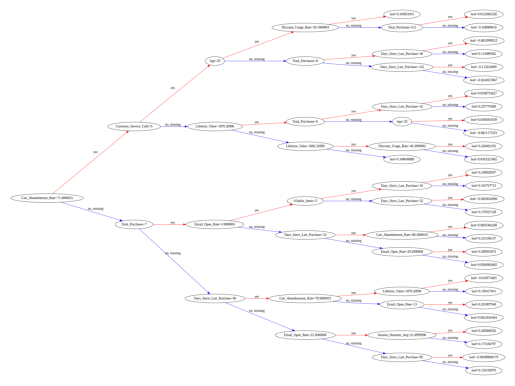

In [11]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Modeldeki ilk ağacı (index 0) çizdirelim
plt.figure(figsize=(40,20))
xgb.plot_tree(model, num_trees=0, rankdir='LR') # LR: Soldan sağa akış
plt.show()


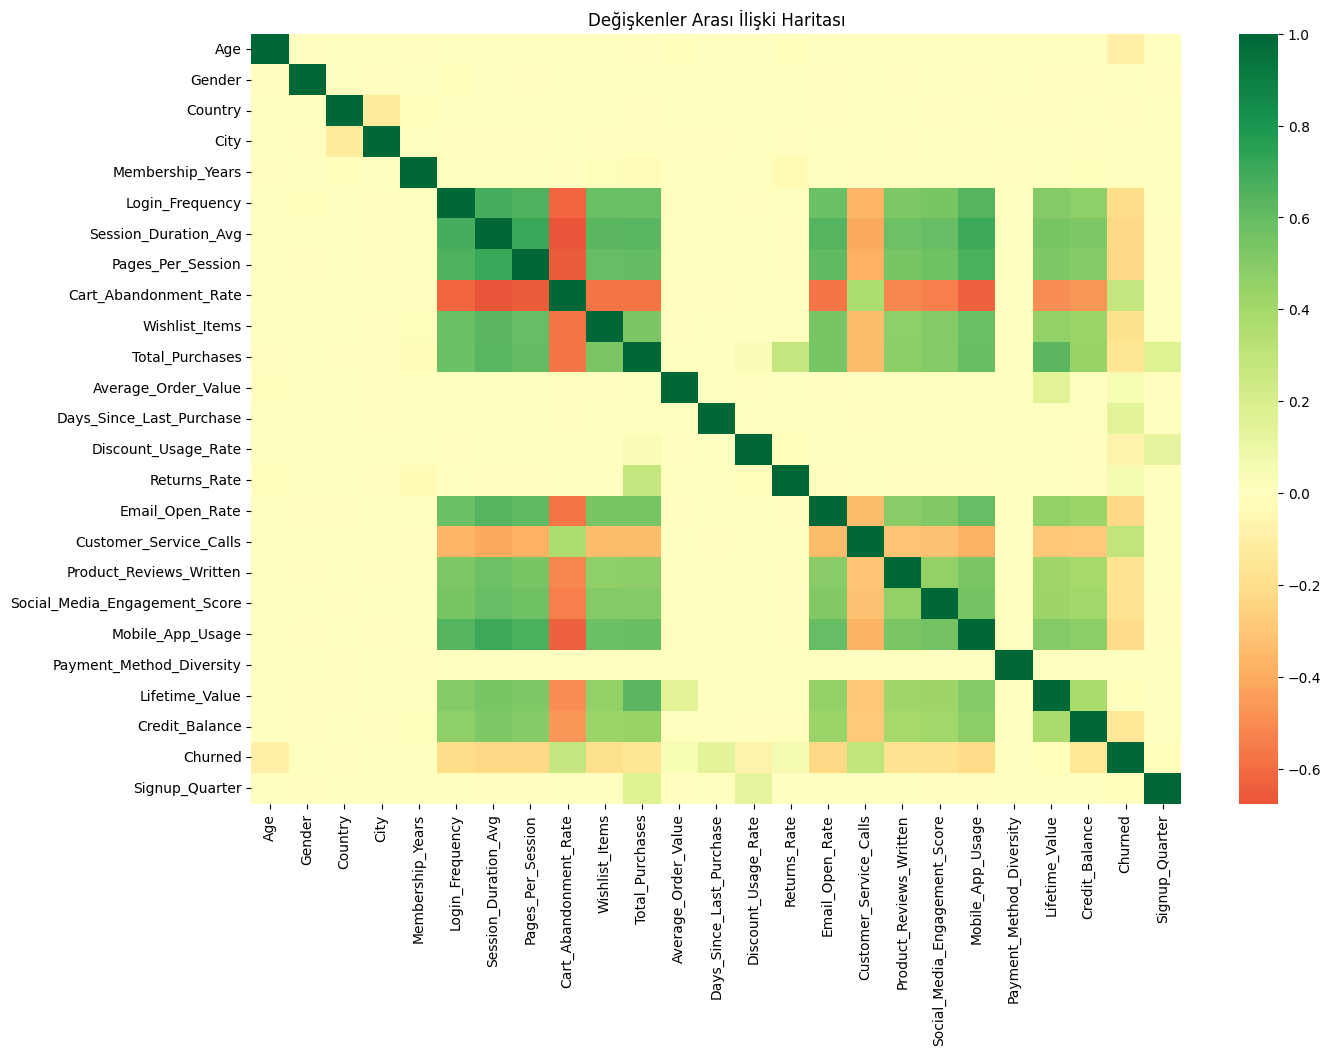

In [12]:
import seaborn as sns

# Sadece sayısal sütunları seçip korelasyon matrisi oluşturalım
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='RdYlGn', center=0)
plt.title("Değişkenler Arası İlişki Haritası")
plt.show()

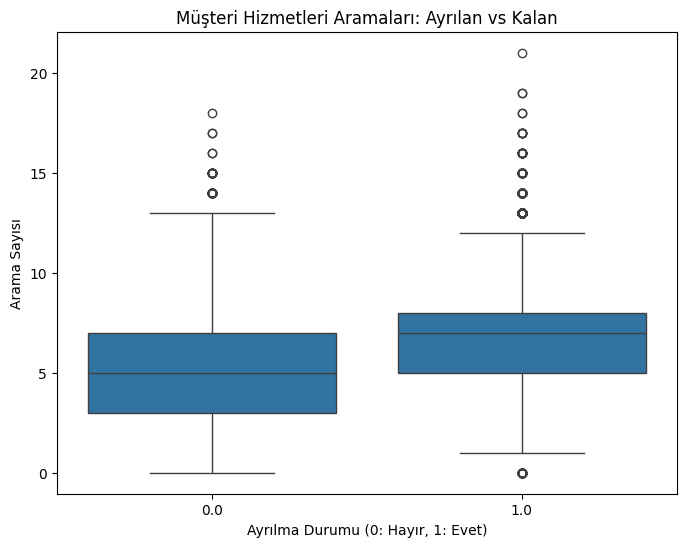

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df)
plt.title("Müşteri Hizmetleri Aramaları: Ayrılan vs Kalan")
plt.xlabel("Ayrılma Durumu (0: Hayır, 1: Evet)")
plt.ylabel("Arama Sayısı")
plt.show()

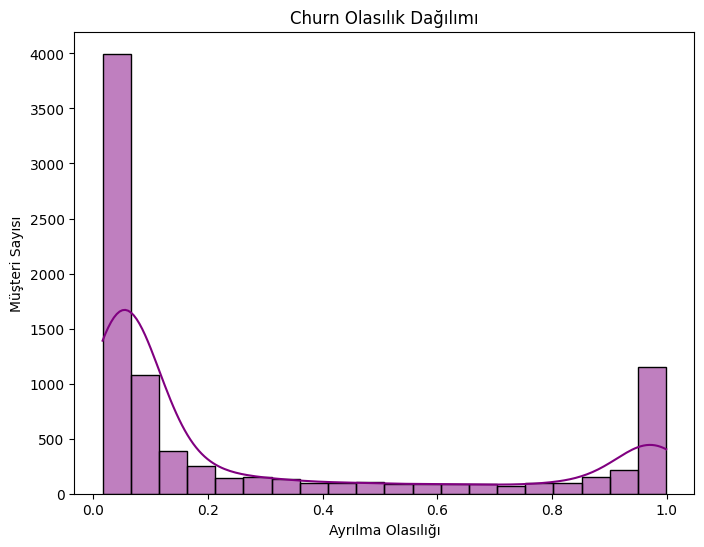

In [14]:
y_probs = model.predict_proba(X_test)[:, 1]
plt.figure(figsize=(8, 6))
sns.histplot(y_probs, bins=20, kde=True, color='purple')
plt.title("Churn Olasılık Dağılımı")
plt.xlabel("Ayrılma Olasılığı")
plt.ylabel("Müşteri Sayısı")
plt.show()

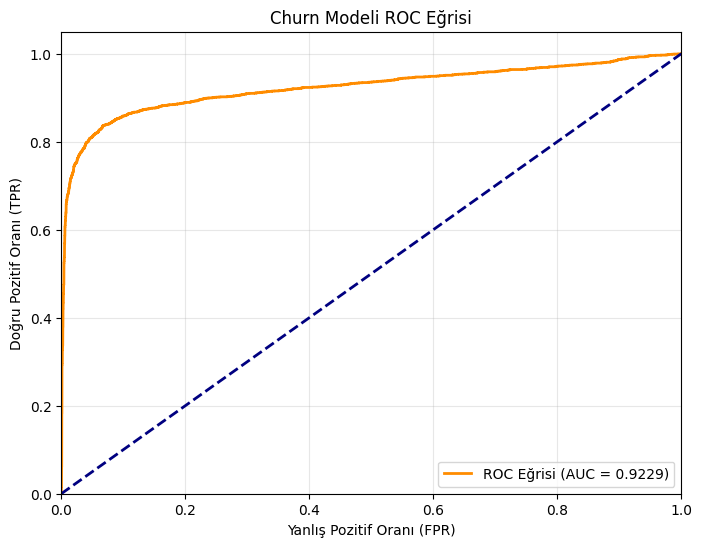

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Olasılıkları alalım (Daha önce almıştık ama garanti olsun)
y_probs = model.predict_proba(X_test)[:, 1]

# 2. ROC eğrisi için değerleri hesaplayalım
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 3. Görselleştirme
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.title('Churn Modeli ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipython-input-2000398491.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df, palette='Set2')


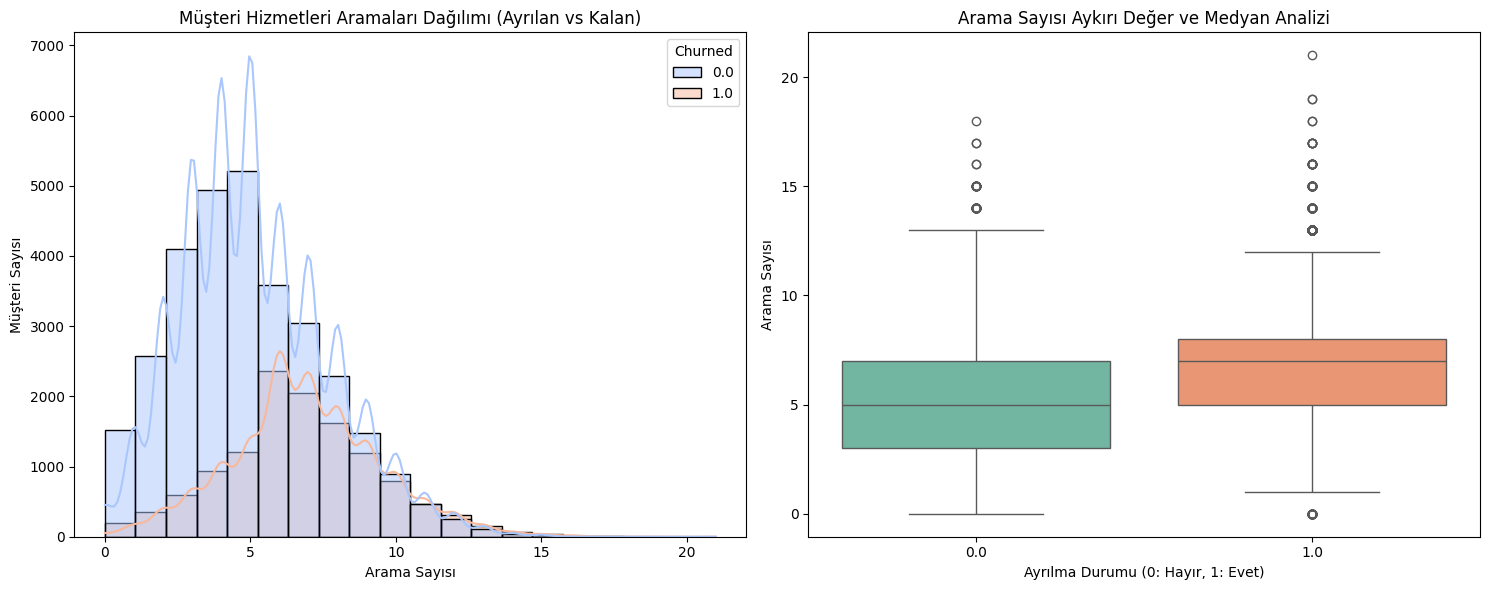

In [16]:
#şikayet sayısı arttıkça müşteri bizi gerçekten bırakıyor mu?" sorusunun somut kanıtını görmüş olacağız.
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme boyutlarını ayarlayalım
plt.figure(figsize=(15,6))

# 1. Grafik: Dağılım (Histogram)
plt.subplot(1,2,1)
sns.histplot(x='Customer_Service_Calls',
             hue='Churned',
             data=df, # Veri seti adın df ise bu şekilde güncelledim
             bins=20, # 40 yerine 20-30 arası daha net bir görünüm verebilir
             kde=True,
             palette='coolwarm')
plt.title('Müşteri Hizmetleri Aramaları Dağılımı (Ayrılan vs Kalan)')
plt.xlabel('Arama Sayısı')
plt.ylabel('Müşteri Sayısı')

# 2. Grafik: Kutu Grafiği (Boxplot)
plt.subplot(1,2,2)
sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df, palette='Set2')
plt.title('Arama Sayısı Aykırı Değer ve Medyan Analizi')
plt.xlabel('Ayrılma Durumu (0: Hayır, 1: Evet)')
plt.ylabel('Arama Sayısı')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
/tmp/ipython-input-1474364733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

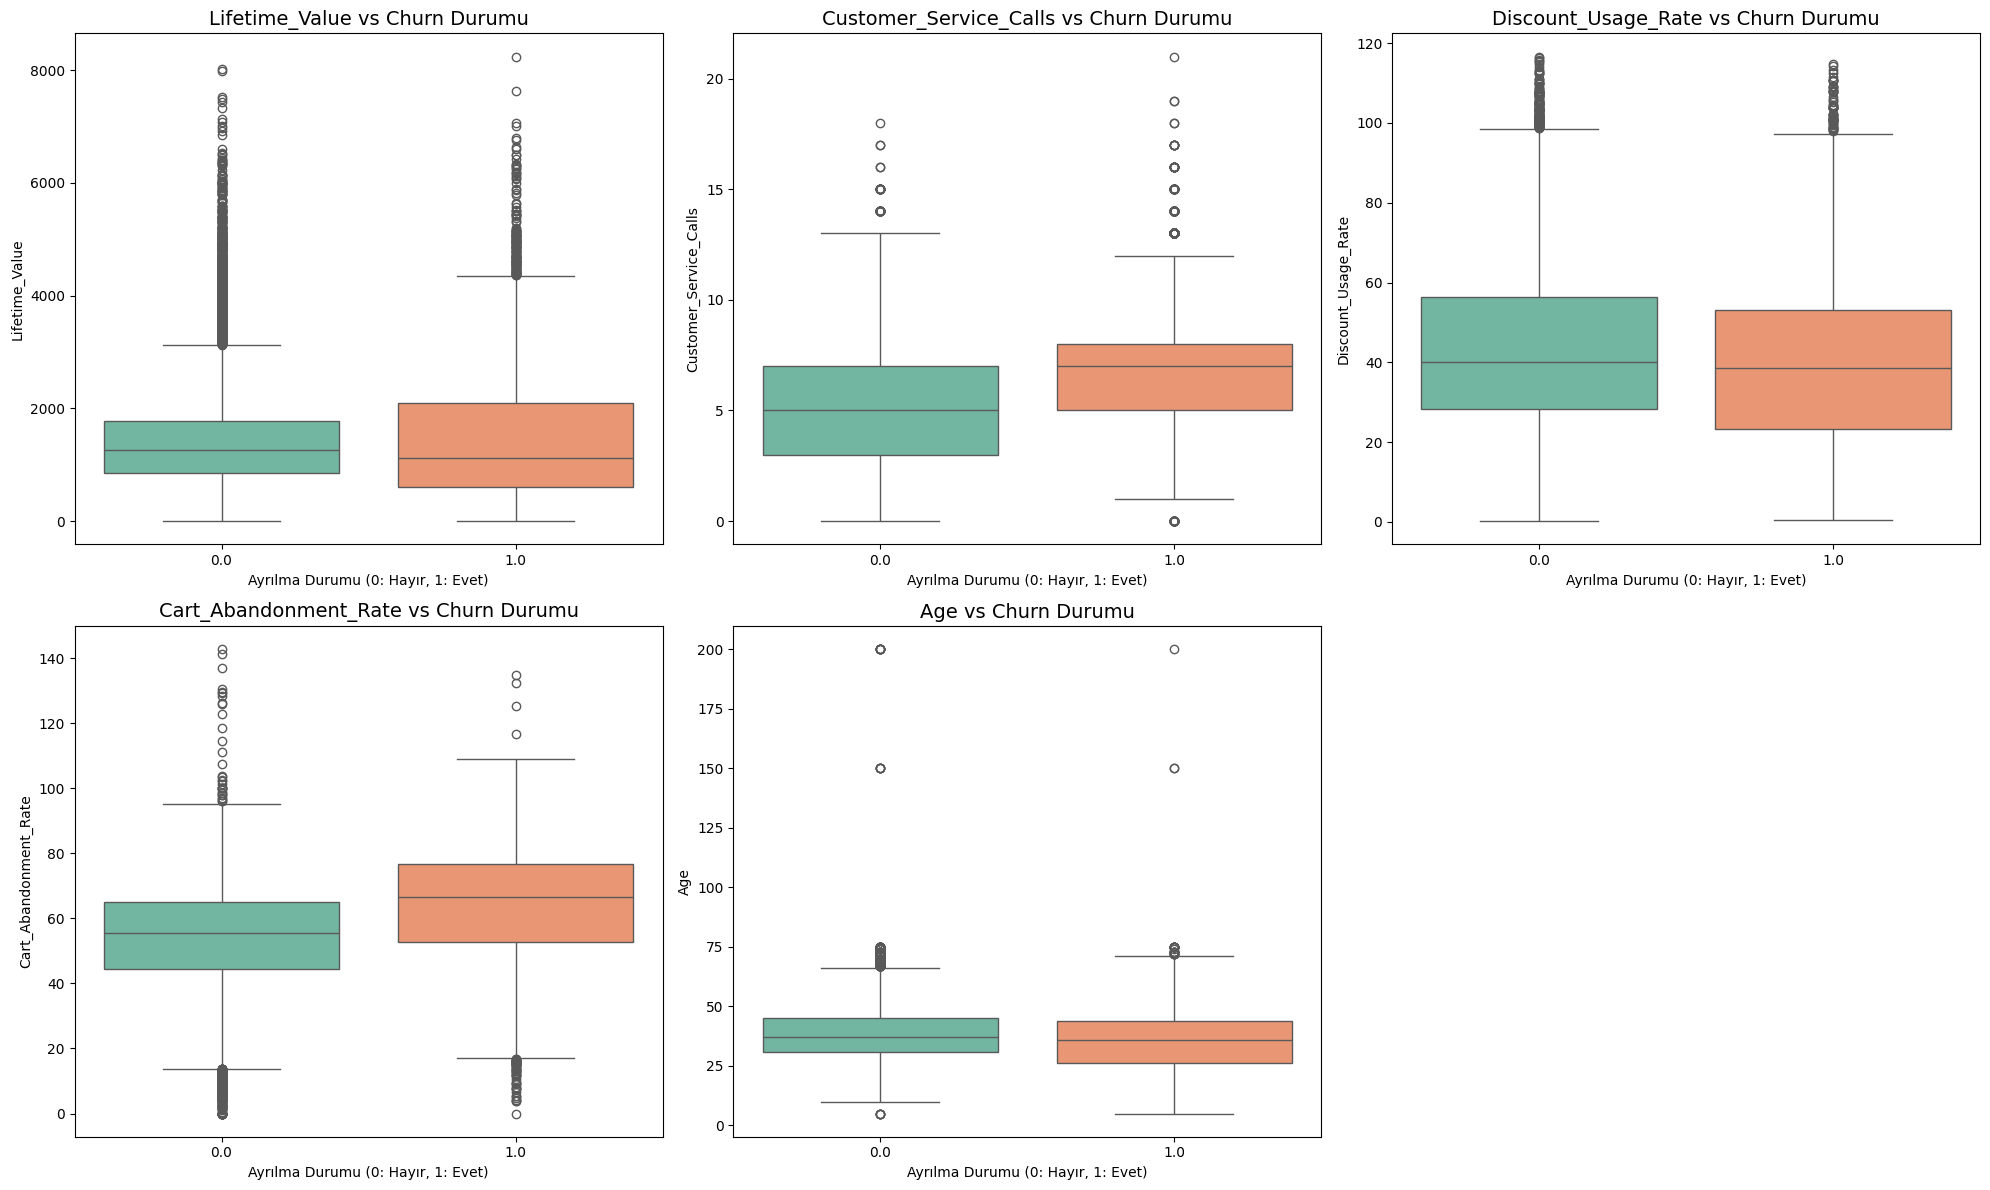

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# En etkili 5 değişkeni listeleyelim
top_5_features = ['Lifetime_Value', 'Customer_Service_Calls', 'Discount_Usage_Rate', 'Cart_Abandonment_Rate', 'Age']

plt.figure(figsize=(20, 12))

for i, col in enumerate(top_5_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Churned', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Churn Durumu', fontsize=14)
    plt.xlabel('Ayrılma Durumu (0: Hayır, 1: Evet)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

/tmp/ipython-input-116078635.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churned'] == 0][col], label='Kalanlar', shade=True, color="blue")
/tmp/ipython-input-116078635.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churned'] == 1][col], label='Ayrılanlar', shade=True, color="red")
/tmp/ipython-input-116078635.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churned'] == 0][col], label='Kalanlar', shade=True, color="blue")
/tmp/ipython-input-116078635.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in se

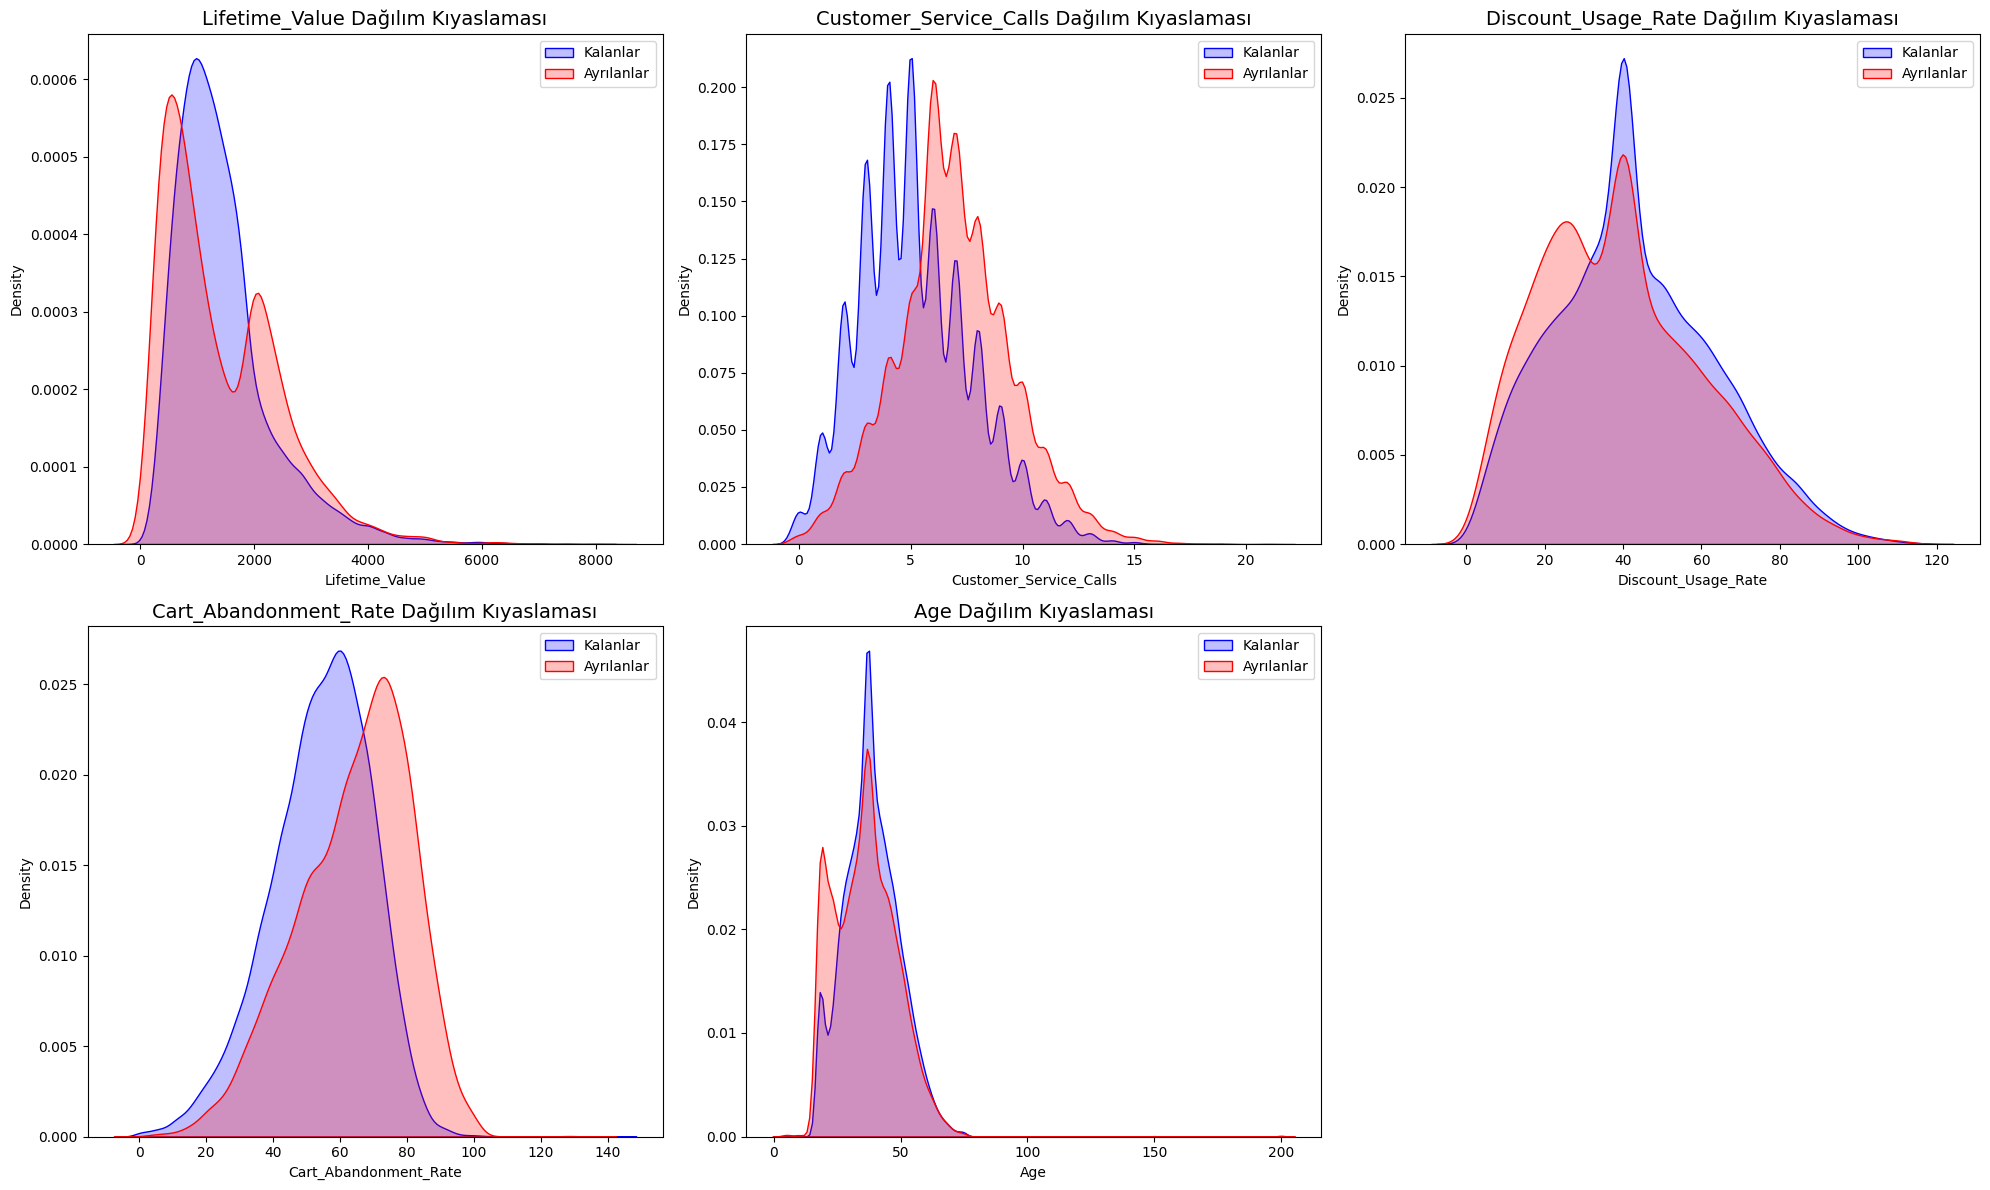

In [33]:
#Yoğunluk ve Eşik Değer Analizi (KDE Plots)
plt.figure(figsize=(20, 12))

for i, col in enumerate(top_5_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df[df['Churned'] == 0][col], label='Kalanlar', shade=True, color="blue")
    sns.kdeplot(data=df[df['Churned'] == 1][col], label='Ayrılanlar', shade=True, color="red")
    plt.title(f'{col} Dağılım Kıyaslaması', fontsize=14)
    plt.legend()

plt.tight_layout()
plt.show()

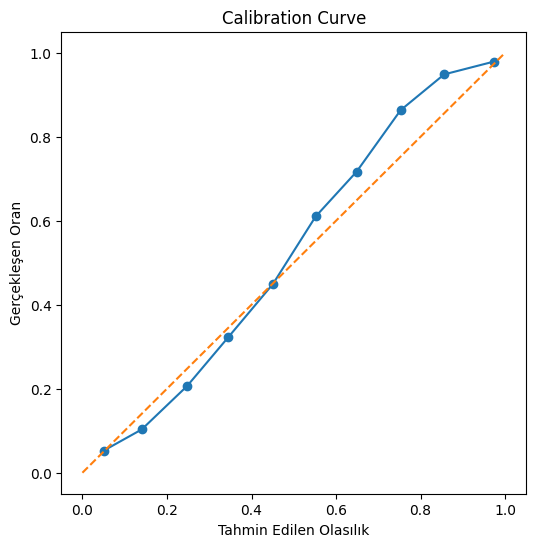

In [19]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Tahmin Edilen Olasılık")
plt.ylabel("Gerçekleşen Oran")
plt.title("Calibration Curve")
plt.show()


In [53]:
display(df.head(20))

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,1,2,21,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0.0,0
1,36.0,1,6,20,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.5,23.3,3.0,1067.47,3028.0,0.0,3
2,45.0,0,1,38,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.5,8.8,2.0,1289.75,2317.0,0.0,3
3,56.0,0,7,27,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0.0,0
4,35.0,1,4,9,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0.0,3
5,35.0,1,5,35,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1.0,0
6,56.0,1,3,2,1.9,24.0,46.4,13.9,36.2,5.0,...,35.5,4.0,6.0,68.8,42.9,5.0,3003.57,2657.0,0.0,0
7,47.0,0,7,13,1.6,14.0,24.1,8.3,59.9,2.0,...,5.5,5.0,2.0,30.1,7.6,2.0,1394.04,2274.0,0.0,3
8,32.0,1,1,5,1.3,14.0,26.7,7.4,66.5,4.0,...,19.0,2.0,0.0,0.0,18.7,2.0,537.21,534.0,0.0,0
9,44.0,1,7,27,3.6,13.0,31.3,5.4,62.6,3.0,...,11.7,2.0,1.0,13.5,21.5,2.0,807.84,977.0,0.0,1


In [58]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

display(df.head(20))

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,1,2,21,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0.0,0
1,36.0,1,6,20,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,27.5,23.3,3.0,1067.47,3028.0,0.0,3
2,45.0,0,1,38,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,27.5,8.8,2.0,1289.75,2317.0,0.0,3
3,56.0,0,7,27,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0.0,0
4,35.0,1,4,9,3.1,29.0,51.4,8.4,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0.0,3
5,35.0,1,5,35,3.5,6.0,21.9,6.9,74.4,0.0,12.0,190.97,29.0,60.20,11.0,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1.0,0
6,56.0,1,3,2,1.9,24.0,46.4,13.9,36.2,5.0,20.0,169.58,10.0,27.80,5.5,35.5,4.0,6.0,68.8,42.9,5.0,3003.57,2657.0,0.0,0
7,47.0,0,7,13,1.6,14.0,24.1,8.3,59.9,2.0,13.0,161.98,6.0,77.16,6.3,5.5,5.0,2.0,30.1,7.6,2.0,1394.04,2274.0,0.0,3
8,32.0,1,1,5,1.3,14.0,26.7,7.4,66.5,4.0,6.0,77.79,13.0,1.80,9.9,19.0,2.0,0.0,0.0,18.7,2.0,537.21,534.0,0.0,0
9,44.0,1,7,27,3.6,13.0,31.3,5.4,62.6,3.0,9.0,90.95,38.0,65.50,5.4,11.7,2.0,1.0,13.5,21.5,2.0,807.84,977.0,0.0,1


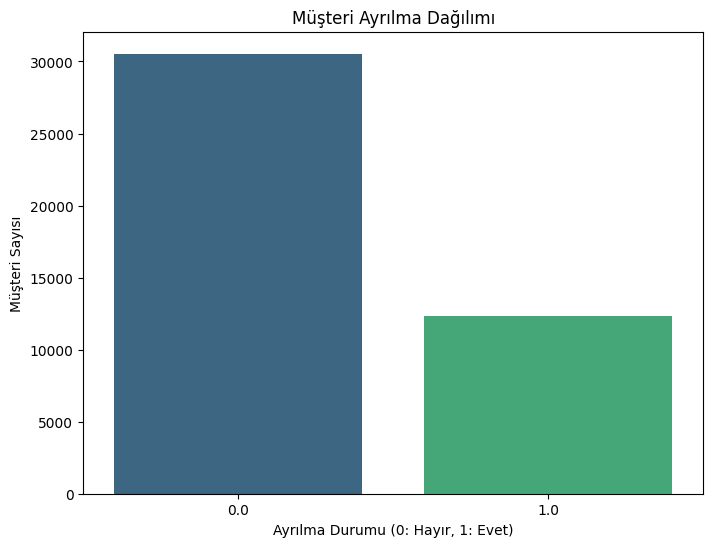

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Churned', data=df, palette='viridis', hue='Churned', legend=False)
plt.title('Müşteri Ayrılma Dağılımı')
plt.xlabel('Ayrılma Durumu (0: Hayır, 1: Evet)')
plt.ylabel('Müşteri Sayısı')
plt.show()

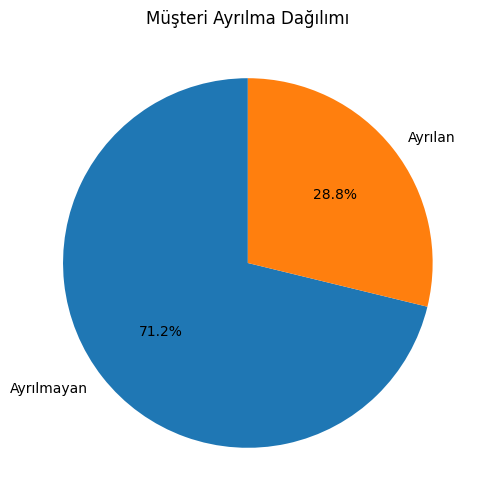

In [52]:
churn_counts = df['Churned'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=['Ayrılmayan', 'Ayrılan'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Müşteri Ayrılma Dağılımı")
plt.show()